# T47 — Thermochronology on paleo-Earth: Central Asian exhumation through deep time

**Adopts the Boone et al. (2025) Communications Earth & Environment workflow for integrating low-temperature thermochronology with plate-tectonic reconstructions. Loads the published 377-sample Central Asia thermal-history compilation (Nixon et al. 2025, hosted on the EarthBank platform), computes per-million-year cooling rates from inverse thermal-history models, reconstructs each sample to its cooling-age paleo-position via `gplately`, and renders the resulting paleo-cooling-rate distribution on top of the contemporaneous Scotese & Wright (2018) (https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/) PaleoDEM. Brings the upstream ThermoPlates shell-script workflow (Boone 2025) into the suite's pyGMT idiom.**

## What this notebook produces

A low-temperature thermochronology age dates the moment a rock cooled through a system-specific closure temperature. Behind that single age is located an *inverse thermal history model* — a best-fit time-temperature path that defines how the rock cooled and exhumed across the full age range constrained by its data. Boone et al. (2025) compiled 381 such inverse thermal-history models for Central Asia (Nixon et al. 2025, hosted on the EarthBank platform) and showed that placing them in paleogeographic context disentangles the geodynamic, tectonic, and climatic drivers of long-term exhumation in continental interiors.

This notebook reproduces the core data-reduction and paleo-reconstruction parts of that workflow in pyGMT + GPlately. Cell 3 loads the bundled tutorial subset, cell 4 computes per-million-year cooling rates per sample, cell 5 reconstructs each sample to its paleo-position at three representative ages (180, 100, 30 Ma) and renders the result on the Scotese & Wright PaleoDEM with Zahirovic 2022 plate boundaries on top, and cell 6 plots cooling-rate-versus-time evolution per regional cluster — separating the Tian Shan from the Altai-Sayan from the Siberian Plain. The downstream steps from Boone et al. (2025) (dynamic-topography overlays, paleoprecipitation correlation, plate-kinematics rose diagrams) are pointed at in *Extend this* — they live in the upstream ThermoPlates repository.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.

## Learning objectives

- Load a published thermal-history compilation in long format (one row per sample per Myr) and reduce it to per-sample cooling-rate time series.
- Reconstruct sample positions to their per-time-step paleo-positions with `gplately` so each cooling pulse is placed in its contemporaneous paleogeographic context.
- Recognise the Boone et al. (2025) classification of cooling rates (fast >0.5 °C/Myr, very fast >1.0 °C/Myr, extra fast >1.5 °C/Myr) and use it to filter the compilation for paleo-map rendering.
- Render thermochronology cooling rates as a coloured point distribution on top of the Scotese & Wright PaleoDEM under Zahirovic 2022 plate boundaries — the suite's canonical paleo-Earth basemap stack.

## Prerequisites and runtime

- **Plate model**: Zahirovic 2022 (Eastern Tethyan focus; matches the choice in Boone et al. 2025).
- **Paleogeography**: Scotese & Wright (2018) PaleoDEMs — path via `PALEODEM_DIR` (same convention as T45).
- **Data**: `data/thermochronology_central_asia/central_asia_thermal_histories.csv` — bundled tutorial subset, 377 samples × 5-Myr-cadence time steps (23 119 rows, 1.2 MB).
- **Python**: `gplately`, `pygmt`, `pygplates`, `xarray`, `pandas`, `numpy`, `matplotlib`.
- **Runtime**: ~2 minutes.

## Data availability

This notebook reads the bundled `data/thermochronology_central_asia/central_asia_thermal_histories.csv`. It is a 5-Myr-cadence downsample of the published Central Asia thermal-history compilation:

- **Boone et al. (2025)**: *Deciphering mantle, tectonic and climatic drivers of exhumation*. *Communications Earth & Environment* 6, 1015. CC BY 4.0. https://doi.org/10.1038/s43247-025-03005-6
- **Nixon, Boone, Meeuws, Kohlmann & Glorie (2025)** — *Central Asia thermochronology compilation*. AuScope EarthBank Platform. https://doi.org/10.58024/AGUA6E7B32B9
- **Upstream code repository** (UNIX shell + GMT 6 scripts): https://github.com/samuelcboone/ThermoPlates

Full-resolution per-Myr data + every sub-region label is on the EarthBank platform (previously AusGeochem; Boone et al. 2023, *Scientific Reports* 13(1), 8581, https://doi.org/10.1038/s41598-023-35776-3). Set `EARTHBANK_URL` in cell 1 to point at the API endpoint when ready to step beyond the bundled subset.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import os
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, xarray as xr
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

# Library versions (printed for reproducibility)
try:
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

In [2]:
# === USER CONFIGURATION =====================================================
HISTORIES_CSV    = "data/thermochronology_central_asia/central_asia_thermal_histories.csv"
REGIONS_CSV      = "data/thermochronology_central_asia/central_asia_regions.csv"
MODEL_NAME       = "Zahirovic2022"
ANCHOR_PLATE_ID  = 0
# Multiple candidate locations: user's env var first, then their
# Paleotopo_data_assimilation clone (1° grids), then the EarthByte
# Workflows clone (6-arcmin grids). The first that contains a file
# matching *_{age}Ma.nc wins.
PALEODEM_DIR_CANDIDATES = [
    os.environ.get("PALEODEM_DIR"),
    str(Path("./external/PaleoDEMs_Scotese_Wright_2018_1deg")),
    str(Path("./external/PaleoDEMs_Scotese_Wright_2018_6min")),
    str(Path("./external/PaleoDEMs_Scotese_Wright_2018")),
]
PALEODEM_DIR_CANDIDATES = [p for p in PALEODEM_DIR_CANDIDATES if p]
# Three Phanerozoic snapshots representative of the Central Asian exhumation history
SNAPSHOT_TIMES_MA = (180.0, 100.0, 30.0)
# Boone et al. 2025 cooling-rate classification thresholds (°C/Myr)
FAST_CR        = 0.5
VERY_FAST_CR   = 1.0
EXTRA_FAST_CR  = 1.5
# Regional zoom — full Central Asian sampling area (Boone et al. 2025 Fig. 1 extent)
REGION_CENTRAL_ASIA = [55, 130, 35, 60]
EARTHBANK_URL    = "https://earthbank.auscope.org.au/"   # for full-resolution API access
# ============================================================================


## 1. Load the Central Asia thermal-history compilation

In [3]:
# Cell 2 — load
hist = pd.read_csv(HISTORIES_CSV, comment="#")
hist.columns = [c.strip() for c in hist.columns]
hist["TOAGE"]      = pd.to_numeric(hist["TOAGE"], errors="coerce")
hist["OnlyCooling"]= pd.to_numeric(hist["OnlyCooling"], errors="coerce")
hist["TempDiff"]   = pd.to_numeric(hist["TempDiff"], errors="coerce")
hist["Region"]     = pd.to_numeric(hist["Region"],     errors="coerce")
print(f"  loaded {len(hist):,} thermal-history rows across {hist.sample_name.nunique()} samples")
print(f"  age window: {hist.TOAGE.min():.0f}–{hist.TOAGE.max():.0f} Ma (5 Myr cadence)")

regions = pd.read_csv(REGIONS_CSV)
print(f"  regions: {regions.region_name.tolist()}")


  loaded 23,119 thermal-history rows across 377 samples
  age window: 0–300 Ma (5 Myr cadence)
  regions: ['Tian Shan', "Ha-erh-lik'o Mts", 'Central Uzbekistan', 'Junggar Basin', 'Gobi-Hami', 'Altai', 'Siberian Plain']


## 2. Compute per-million-year cooling rates from the thermal-history models

For each sample we differentiate the inverse-modelled temperature path to get a
cooling rate per Myr. Following Boone et al. (2025) we treat reheating phases
as 0 °C/Myr cooling (they don't record exhumation) and ignore unconstrained
time intervals.

In [4]:
# Cell 3 — per-sample cooling-rate time series
# Use the TempDiff column AS-IS — this is Boone et al. 2025's
# pre-computed per-sample, per-5-Myr cooling rate (column 7 of the
# source CSV in ThermoPlates / 01_Thermochronology_Assessment.sh).
# Recomputing from OnlyCooling differences gives DIFFERENT (and
# wrong) values, because OnlyCooling is the cooling-only minimum-
# temperature envelope at each age, not the instantaneous T(t).
hist = hist.sort_values(["sample_name", "TOAGE"]).reset_index(drop=True)
cr = hist.rename(columns={"TempDiff": "cooling_rate"}).copy()
cr = cr.dropna(subset=["cooling_rate","lat","lon"])
print(f"  computed cooling rates for {len(cr):,} (sample, time) pairs")
print(f"  cooling rate distribution:")
for thr, lbl in [(FAST_CR,"fast >0.5"), (VERY_FAST_CR,"very fast >1.0"),
                  (EXTRA_FAST_CR,"extra fast >1.5")]:
    pct = 100 * (cr.cooling_rate >= thr).mean()
    print(f"    {lbl} °C/Myr: {pct:5.1f} % of (sample, time) pairs")


  computed cooling rates for 11,542 (sample, time) pairs
  cooling rate distribution:
    fast >0.5 °C/Myr:  44.9 % of (sample, time) pairs
    very fast >1.0 °C/Myr:  24.8 % of (sample, time) pairs
    extra fast >1.5 °C/Myr:  15.2 % of (sample, time) pairs


## 3. Three reconstructed paleo-Earth snapshots — cooling rates on the Scotese & Wright PaleoDEM

For each snapshot age `t` we (i) keep cooling-rate values at that age, (ii) reconstruct each sample's present-day lon/lat to the contemporaneous paleo-position with `gplately`, (iii) draw the result on top of the Scotese & Wright PaleoDEM with Zahirovic 2022 reconstructed plate boundaries layered on top. Symbol size encodes the Boone et al. (2025) cooling-rate class (fast / very fast / extra fast).

  180 Ma: 171 (sample, t) pairs reconstructed


  100 Ma: 287 (sample, t) pairs reconstructed


  30 Ma: 299 (sample, t) pairs reconstructed


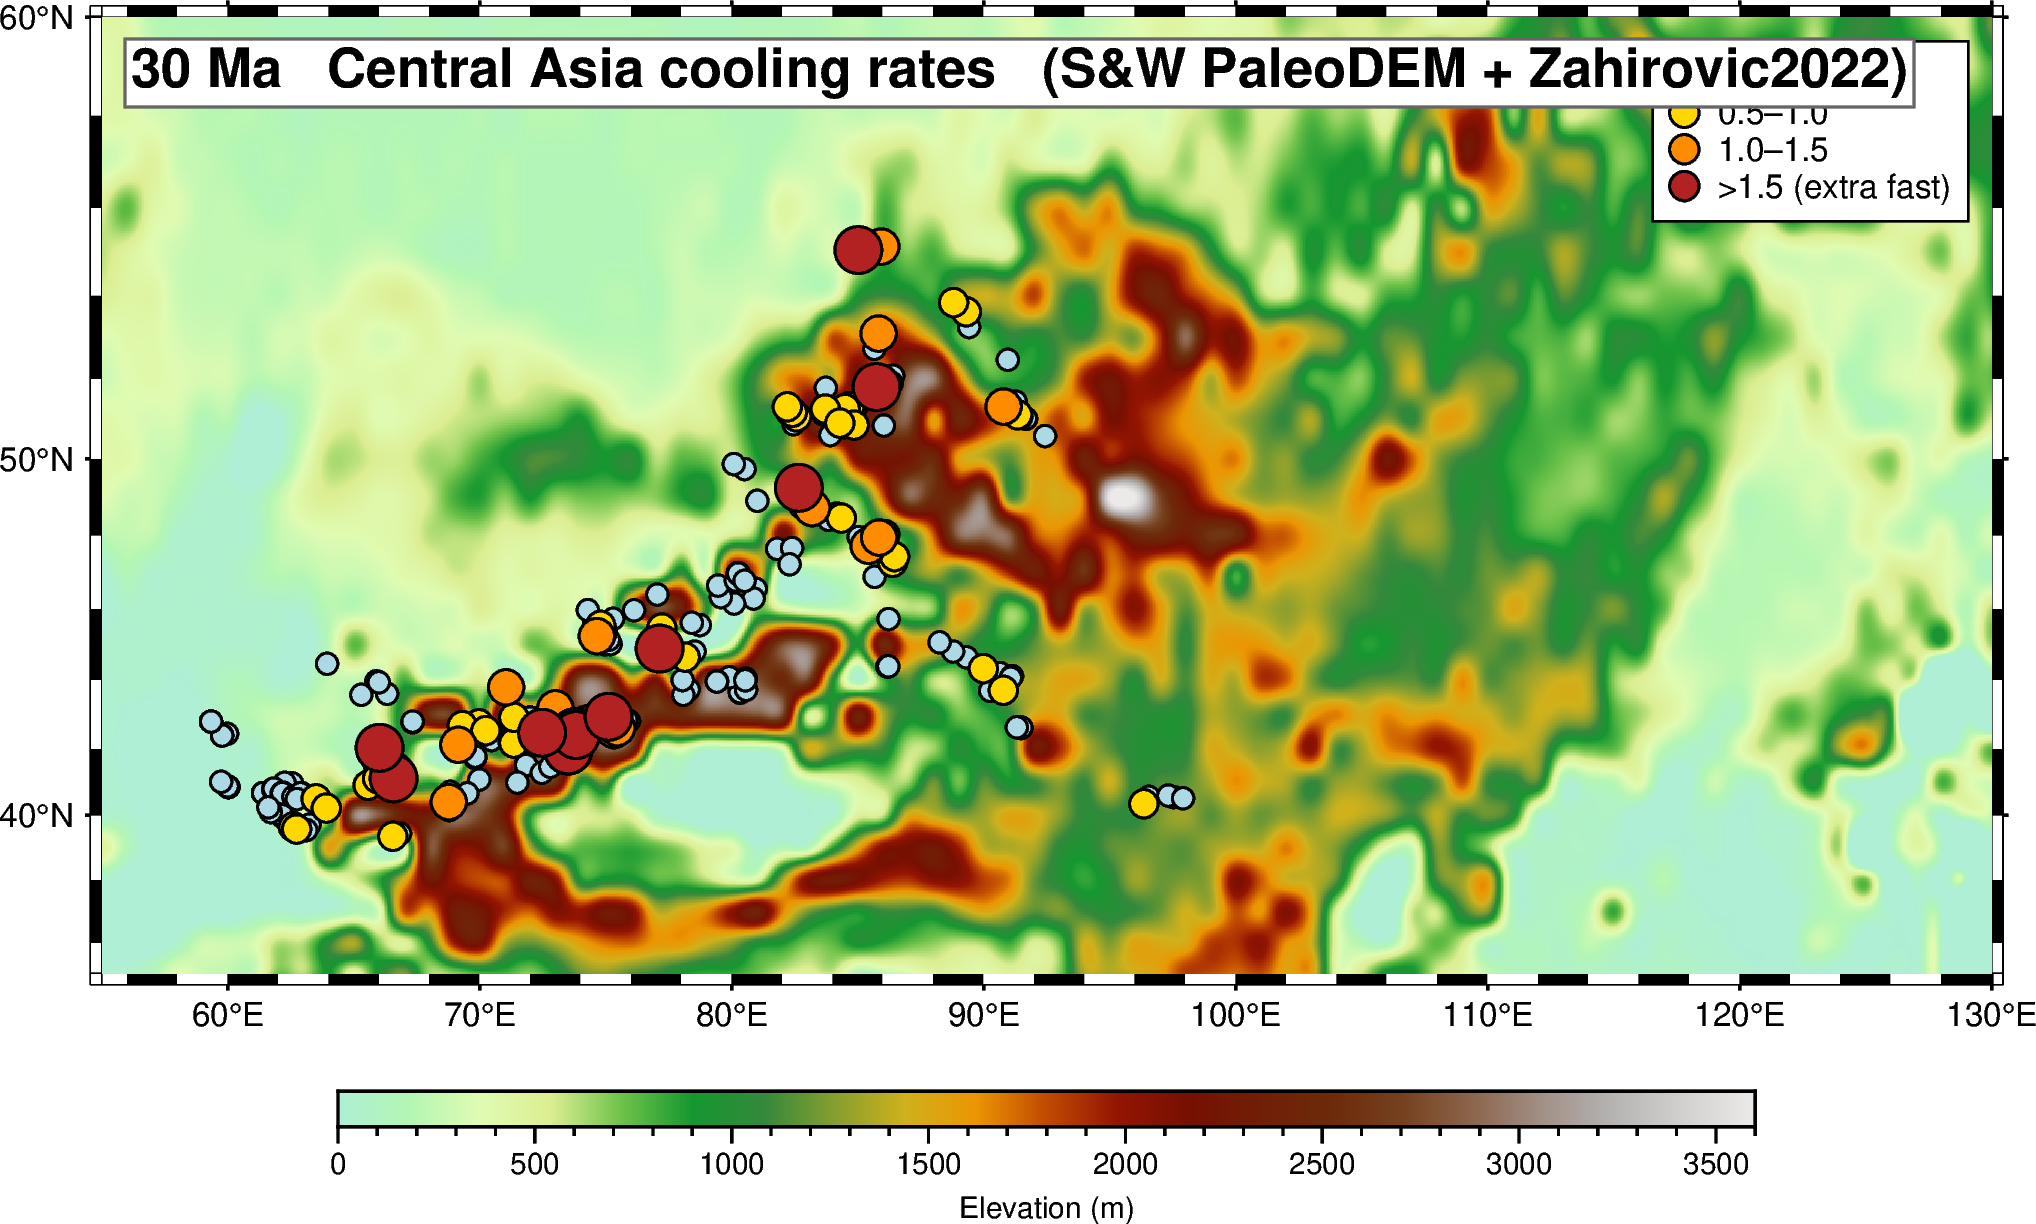

In [5]:
# Cell 4 — three Central Asia paleo-Earth snapshots
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons())

def load_paleodem(t):
    """Locate the Scotese & Wright PaleoDEM nearest to time `t` (Ma).
    Globs each candidate directory for any file ending in '_<int_t>Ma.nc'
    — this matches both the published `Map##_PALEOMAP_*deg_*_<age>Ma.nc`
    convention and any user-renamed file ending in '<age>Ma.nc'."""
    ti = int(round(t))
    for base in PALEODEM_DIR_CANDIDATES:
        base_p = Path(base).expanduser()
        if not base_p.exists():
            continue
        hits = sorted(base_p.glob(f"*_{ti}Ma.nc"))
        if hits:
            return xr.open_dataset(hits[0])
    raise FileNotFoundError("\n".join([
        f"No PaleoDEM at {t} Ma anywhere under PALEODEM_DIR_CANDIDATES:",
        f"  searched = {PALEODEM_DIR_CANDIDATES}",
        f"  Download from https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/",
    ]))

for t in SNAPSHOT_TIMES_MA:
    # Slice the cooling-rate stack at this age
    snap = cr[cr.TOAGE == int(t)].copy()
    if snap.empty:
        print(f"  {t:.0f} Ma: no thermal-history coverage at this age — skipping")
        continue

    # Reconstruct each sample to its paleo-position at this age
    plon, plat = [], []
    for _, row in snap.iterrows():
        pt = gplately.Points(recon, [row["lon"]], [row["lat"]])
        rl, rla = pt.reconstruct(float(t), return_array=True)
        plon.append(float(rl[0])); plat.append(float(rla[0]))
    snap["paleo_lon"] = plon
    snap["paleo_lat"] = plat
    print(f"  {t:.0f} Ma: {len(snap)} (sample, t) pairs reconstructed")

    # PaleoDEM + plate boundaries
    dem = load_paleodem(t)
    var = next((v for v in dem.data_vars
                if any(k in v.lower() for k in ("elev","topo","dem","z"))),
               list(dem.data_vars)[0])
    elev = dem[var]

    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(), time=float(t),
        plot_engine=gplately.PygmtPlotEngine(),
        )

    fig = pygmt.Figure()
    fig.basemap(region=REGION_CENTRAL_ASIA, projection="M16c", frame=["af"])
    # Clip the elevation colour scale to the actual land-max in the
    # zoomed region (user directive 2026-06-19). Use GMT's dem4 palette
    # — vivid blue->green->yellow->orange->red, well-differentiated.
    # Cropped-region max is computed BEFORE makecpt so the bar tightly
    # tracks the data.
    _zoom = elev.sel(
        lon=slice(REGION_CENTRAL_ASIA[0], REGION_CENTRAL_ASIA[1]),
        lat=slice(REGION_CENTRAL_ASIA[2], REGION_CENTRAL_ASIA[3])) \
        if "lon" in elev.coords and "lat" in elev.coords else elev
    _land_max = float(np.nanmax(_zoom.where(_zoom > 0).values)) if (_zoom > 0).any() else 4000.0
    _land_max = max(500.0, round(_land_max, -2))   # round up to nearest 100 m, floor 500
    pygmt.makecpt(cmap="dem4", series=[0, _land_max, _land_max / 20],
                  background="o", continuous=True)
    fig.grdimage(elev, cmap=True, dpi=200)
    fig.colorbar(frame=[f"af+lElevation (m)"],
                 position="JBC+w12c/0.3c+h+o0/1.0c")
    gplot.plot_all_topological_sections(fig, pen="0.6p,gray20")
    (_tl, _tr) = gplot.get_subduction_direction()
    gplot.plot_subduction_teeth(fig, color="black")

    # Cooling-rate classes: extra-fast on top (largest, white border)
    for thr_lo, thr_hi, sym, col, lbl in [
        (0.0,          FAST_CR,        "c0.18c", "lightblue",  "<0.5 °C/Myr"),
        (FAST_CR,      VERY_FAST_CR,   "c0.24c", "gold",       "0.5–1.0"),
        (VERY_FAST_CR, EXTRA_FAST_CR,  "c0.30c", "darkorange", "1.0–1.5"),
        (EXTRA_FAST_CR,1e9,            "c0.40c", "firebrick",  ">1.5 (extra fast)"),
    ]:
        sub = snap[(snap.cooling_rate >= thr_lo) & (snap.cooling_rate < thr_hi)]
        if len(sub) == 0: continue
        fig.plot(x=sub["paleo_lon"], y=sub["paleo_lat"], style=sym,
                 fill=col, pen="0.6p,black", label=f"{lbl}+S0.25c")

    fig.legend(position="JTR+jTR+o0.2c", box="+gwhite+p0.5p")
    fig.text(text=f"{t:.0f} Ma   Central Asia cooling rates   (S&W PaleoDEM + {MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="13p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=1000)
    display(HTML('<div style="height:1cm"></div>'))


## 4. Per-region cooling-rate evolution through time

Following Boone et al. (2025) §"Plate kinematics and subduction dynamics" we
collapse the per-sample stack to per-region time series, asking when each
geological province experienced its fastest exhumation. Tian Shan, Altai, and
the Siberian Plain are expected to show diachronous exhumation peaks if the
Boone et al. (2025) "reactivation of pre-Mesozoic shear zones in response to
Tethyan subduction dynamics" story holds.

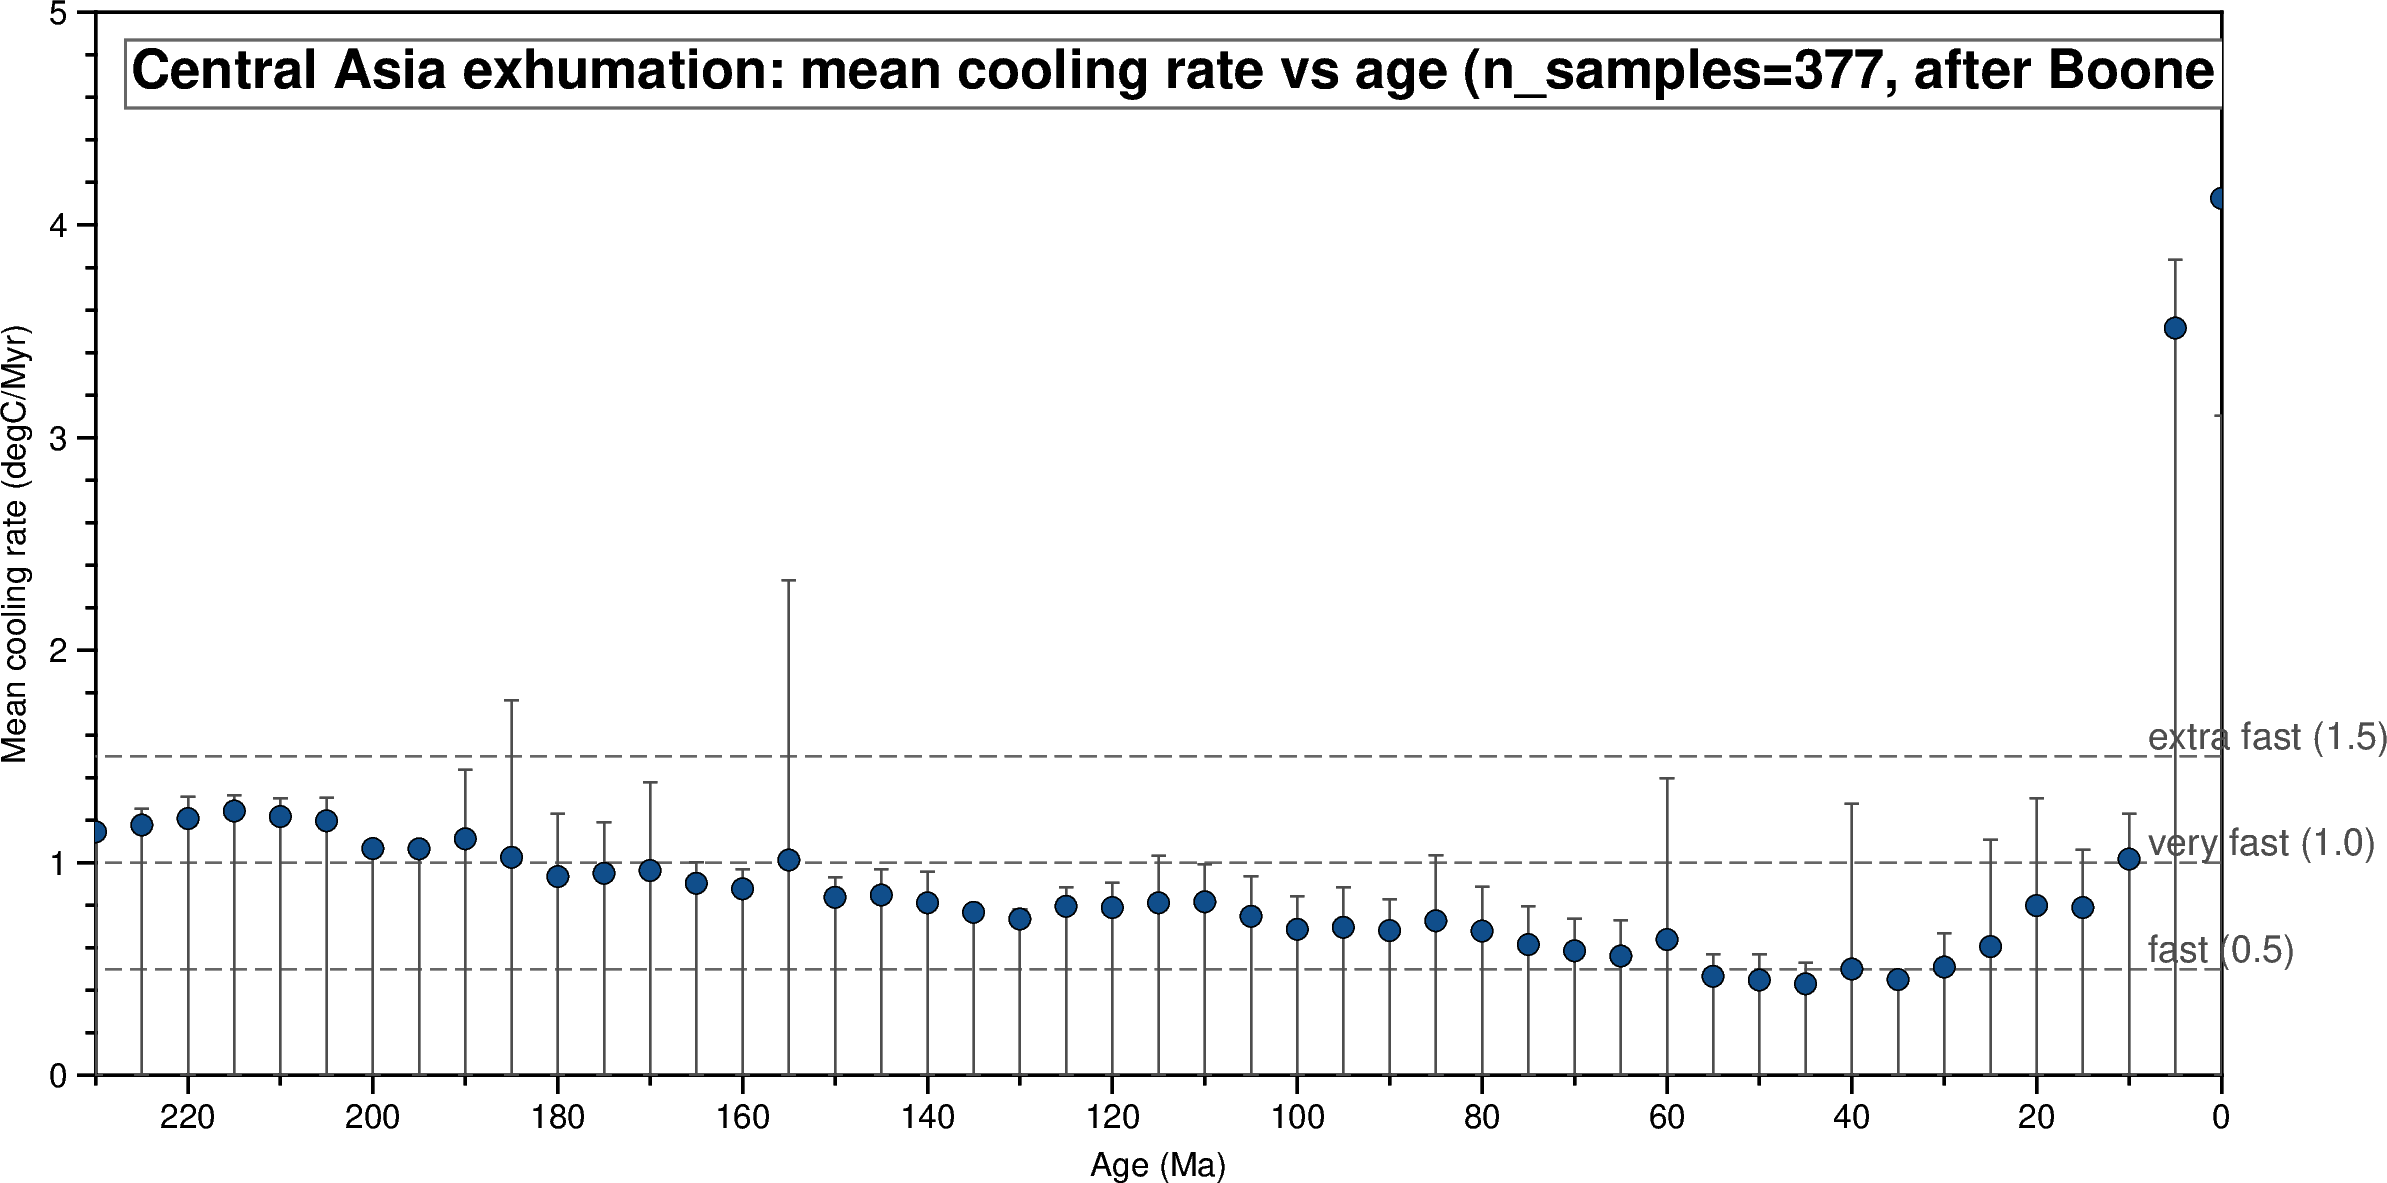

In [6]:
# Cell 5 — Mean cooling rate vs age (pyGMT port of Boone 08_MeansvAge.sh)
# Replicates Boone et al. (2025)'s ThermoPlates/08_MeansvAge.sh aggregation
# (https://github.com/samuelcboone/ThermoPlates): for every age 0-230 Ma,
# compute mean and standard deviation of cooling_rate across all samples
# with valid data at that age. Plot as a single pyGMT scatter with ±SD
# vertical error bars. Y-axis capped at 5 degC/Myr per user directive.

agg = (cr.groupby("TOAGE")
         .agg(mean_cr=("cooling_rate","mean"),
              std_cr =("cooling_rate","std"),
              n      =("cooling_rate","count"))
         .reset_index()
         .sort_values("TOAGE"))

# Prepare 3-column data for pyGMT error-bar plotting (x, y, err_y)
_err_data = pd.DataFrame({
    "x":   agg["TOAGE"].values.astype(float),
    "y":   agg["mean_cr"].values.astype(float),
    "err": agg["std_cr"].fillna(0).values.astype(float),
})

fig = pygmt.Figure()
# Negative projection width inverts the x axis (Phanerozoic flow:
# older on the left, younger on the right).
fig.basemap(region=[0, 230, 0, 5],
            projection="X-18c/9c",
            frame=["xaf+lAge (Ma)",
                   "yaf+lMean cooling rate (degC/Myr)",
                   "WSrt"])

# Boone's classification thresholds (horizontal dashed lines)
for thr, lab in [(FAST_CR,        "fast (0.5)"),
                 (VERY_FAST_CR,   "very fast (1.0)"),
                 (EXTRA_FAST_CR,  "extra fast (1.5)")]:
    fig.plot(x=[0, 230], y=[thr, thr], pen="0.5p,gray40,dashed")
    fig.text(x=8, y=thr + 0.10, text=lab, font="9p,Helvetica,gray30",
             justify="ML", no_clip=True)

# Scatter + vertical error bars from x, y, y_err triplets
fig.plot(data=_err_data,
         style="c0.18c", fill="dodgerblue4",
         pen="0.25p,black",
         error_bar="Y+p0.5p,gray30+w0.12c")

fig.text(text=f"Central Asia exhumation: mean cooling rate vs age "
              f"(n_samples={cr.sample_name.nunique()}, after Boone et al. 2025)",
         position="TL", offset="0.3c/-0.3c", justify="TL",
         font="13p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1300)
display(HTML('<div style="height:1cm"></div>'))


## 5. Paleo-trajectories of representative samples through the Phanerozoic

A pure-`gplately` exercise: for one representative sample from each of
the three numerically-largest regions (Tian Shan, Altai, Siberian Plain),
reconstruct its position every 10 Myr from 0 to 230 Ma using the loaded
`PlateReconstruction`. The resulting polyline shows where on Earth each
locality sat through the late Paleozoic and Mesozoic — a visual reminder
that the cooling-rate signal in Section 4 is recorded by rocks at
*paleo-positions* far from where we collect them today.

The plot is built with `gplately.Points(...).reconstruct(time)` for the
geometry and rendered with pyGMT on a Robinson global basemap. This is
the most direct illustration of the suite's premise — that GPlately
generates the reconstruction, pyGMT renders the figure.


  Tian Shan           modern (41.71 N, 73.00 E)
                    mantle frame -> 230 Ma (47.17 N, 59.32 E)
                    PMAG   frame -> 230 Ma (55.18 N, 73.30 E)
  Altai               modern (47.04 N, 89.51 E)
                    mantle frame -> 230 Ma (60.08 N, 60.23 E)
                    PMAG   frame -> 230 Ma (67.90 N, 78.13 E)
  Siberian Plain      modern (54.20 N, 89.51 E)
                    mantle frame -> 230 Ma (61.93 N, 45.93 E)
                    PMAG   frame -> 230 Ma (70.61 N, 59.33 E)


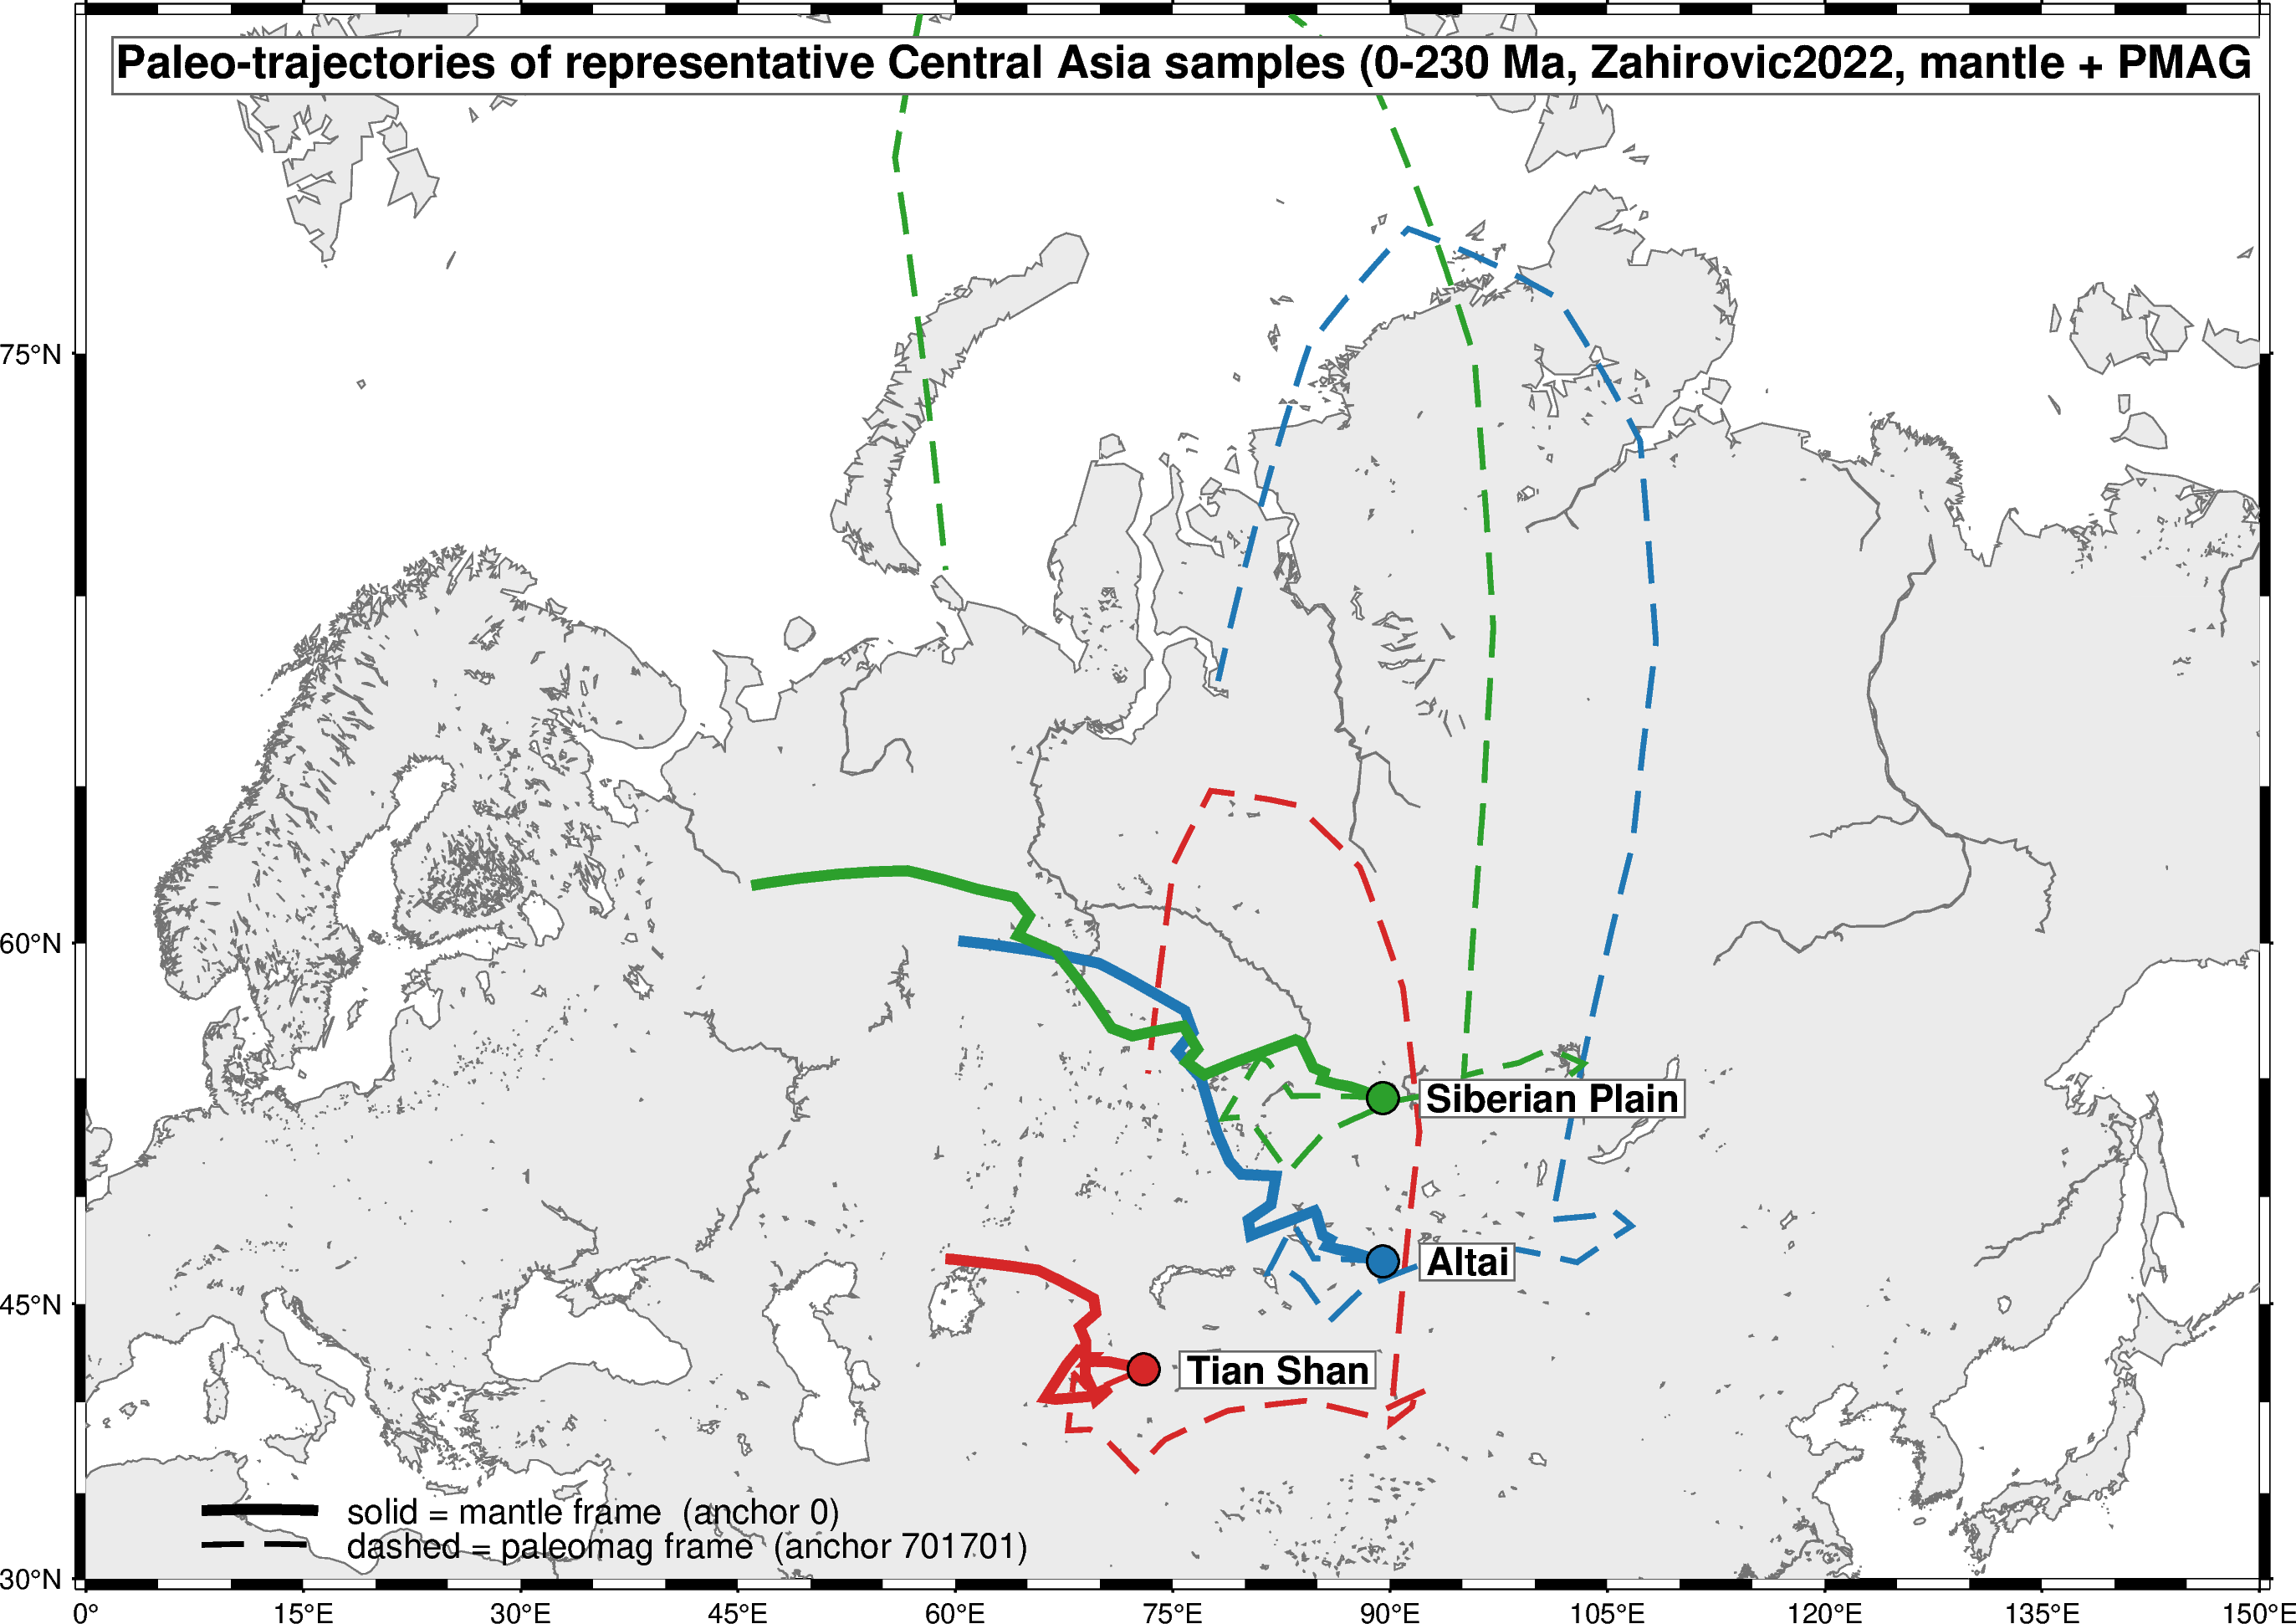

In [7]:
# Cell 6 — pure-gplately paleo-trajectories, rendered with pyGMT
# Pick one representative sample per major region. Take the modern
# (lat, lon) of the first sample listed for each region in regions.csv,
# falling back to a region centroid if there are no samples there.
def _first_sample_coord(region_id):
    mask = (cr.Region == region_id)
    if mask.any():
        row = cr[mask].iloc[0]
        return float(row["lon"]), float(row["lat"])
    # No data for this region — use a placeholder centroid
    return (75.0, 42.0)

# Three regions of interest (region_id codes from regions.csv)
TRAJ_REGIONS = {
    "Tian Shan":       1,
    "Altai":           6,
    "Siberian Plain":  7,
}
TRAJ_COLOURS = ["#d62728", "#1f77b4", "#2ca02c"]
TRAJ_TIMES   = np.arange(0, 231, 10)   # 0, 10, 20, …, 230 Ma

# Paleomag-frame anchor: 701701 for Zahirovic2022 (0-410 Ma paleomag frame)
# is the right frame for any paleoclimate / paleo-latitude comparison;
# mantle frame (anchor=0) is the right frame for tracking points moving
# over the convecting mantle. Both are scientifically meaningful for
# thermochronology: PMAG tells you what climate the sample was sitting
# under; mantle frame tells you whether the sample was over a
# subduction zone, plume, etc.
PMAG_ANCHOR_ID    = 701701   # Zahirovic 2022 African-plate paleomag anchor
MANTLE_ANCHOR_ID  = 0        # default mantle (no-net-rotation) frame

def _reconstruct_trajectory(lon0, lat0, anchor):
    pts = gplately.Points(recon, [lon0], [lat0], anchor_plate_id=anchor)
    rlons, rlats = [], []
    for t in TRAJ_TIMES:
        rl, rla = pts.reconstruct(float(t), return_array=True,
                                  anchor_plate_id=anchor)
        rlons.append(float(rl[0])); rlats.append(float(rla[0]))
    return rlons, rlats

trajectories = {}
for name, rid in TRAJ_REGIONS.items():
    lon, lat = _first_sample_coord(rid)
    mantle_lons, mantle_lats = _reconstruct_trajectory(lon, lat, MANTLE_ANCHOR_ID)
    pmag_lons,   pmag_lats   = _reconstruct_trajectory(lon, lat, PMAG_ANCHOR_ID)
    trajectories[name] = dict(
        modern_lon=lon, modern_lat=lat,
        mantle=(mantle_lons, mantle_lats),
        pmag  =(pmag_lons,   pmag_lats),
    )
    print(f"  {name:18s}  modern ({lat:.2f} N, {lon:.2f} E)")
    print(f"    {' '*14}  mantle frame -> 230 Ma "
          f"({mantle_lats[-1]:.2f} N, {mantle_lons[-1]:.2f} E)")
    print(f"    {' '*14}  PMAG   frame -> 230 Ma "
          f"({pmag_lats[-1]:.2f} N, {pmag_lons[-1]:.2f} E)")

# Eurasia-only extent (lon_min, lon_max, lat_min, lat_max). Wide enough
# to catch both mantle-frame and PMAG-frame paleo-positions at 230 Ma.
REGIONAL_BBOX = [0, 150, 30, 80]
fig = pygmt.Figure()
fig.basemap(region=REGIONAL_BBOX, projection="M22c", frame=["af"])
fig.coast(land="gray92", shorelines="0.4p,gray45")

for (name, traj), colour in zip(trajectories.items(), TRAJ_COLOURS):
    mantle_lons, mantle_lats = traj["mantle"]
    pmag_lons,   pmag_lats   = traj["pmag"]
    lon0, lat0               = traj["modern_lon"], traj["modern_lat"]

    # --- mantle-frame trajectory: SOLID line ---
    fig.plot(x=mantle_lons, y=mantle_lats, pen=f"3p,{colour}")
    # --- PMAG-frame trajectory: DASHED line ---
    fig.plot(x=pmag_lons, y=pmag_lats, pen=f"1.5p,{colour},dashed")

    # Single starting-point marker at the modern (0 Ma) sample position.
    # Both trajectories start here, so one marker suffices and the map
    # stays uncluttered.
    fig.plot(x=lon0, y=lat0, style="c0.32c",
             fill=colour, pen="0.6p,black")

    # Region label at the modern position
    fig.text(x=lon0 + 3, y=lat0, text=name,
             font="11p,Helvetica-Bold,black", justify="ML",
             fill="white", pen="0.5p,gray40",
             clearance="0.08c/0.04c+to")

# Legend explaining the two frame conventions
fig.plot(x=[8, 16], y=[34, 34], pen="3p,black")
fig.text(x=18, y=34, text="solid = mantle frame  (anchor 0)",
         font="10p,Helvetica,black", justify="ML")
fig.plot(x=[8, 16], y=[32, 32], pen="1.5p,black,dashed")
fig.text(x=18, y=32, text="dashed = paleomag frame  (anchor 701701)",
         font="10p,Helvetica,black", justify="ML")

fig.text(text=f"Paleo-trajectories of representative Central Asia samples "
              f"(0-{int(TRAJ_TIMES.max())} Ma, {MODEL_NAME}, mantle + PMAG frames)",
         position="TL", offset="0.3c/-0.3c", justify="TL",
         font="13p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1300)
display(HTML('<div style="height:1cm"></div>'))


### What this map shows

For each of three representative samples (one per major region in the
Boone et al. 2025 compilation), two paleo-trajectories are drawn:

- **Solid bold line — mantle reference frame** (`anchor_plate_id=0`,
  Zahirovic 2022's default no-net-rotation frame). This is where the
  sample sat with respect to the convecting mantle — the relevant
  frame for asking whether the sample was over a subduction zone, a
  hot anomaly, or a stable slab graveyard at a given age.
- **Dashed thin line — paleomagnetic reference frame**
  (`anchor_plate_id=701701`, Zahirovic 2022's African-plate paleomag
  anchor (the Z22 paleomag-frame default for paleoclimate
  context). This is where the sample sat with respect to the spin axis
  — the relevant frame for asking what paleo-latitude (and therefore
  what climate band) the sample was experiencing.

The two trajectories generally agree to first order but diverge by
several degrees of latitude through the Mesozoic because of cumulative
true polar wander between the mantle and spin-axis frames. The
exhumation-vs-paleoclimate story in Section 4 lives in the **paleomag**
frame; an exhumation-vs-mantle-dynamics story would live in the
**mantle** frame.

A filled circle marks each sample's modern (0 Ma) position; the two
trajectories diverge from there as you read back in time. Each region
gets its own colour.


## Extend this

- **Dynamic-topography overlay.** Boone et al. (2025) overlay the same cooling-rate fields on the Braz et al. dynamic-topography prediction (preferred model D10) and report Pearson correlation coefficients per time step. Drop in a DT raster series (e.g., from cluster F's Dhungana & Flament 2025 (https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity) mantle-flow output) and reproduce their `06_Correlation_Analysis.sh` plot.
- **Paleoprecipitation correlation.** The Boone et al. (2025) `03_Thermochron_GPlates.sh` pipeline also overlays HadCM3 paleoprecipitation rates from the BRIDGE archive. T40 in this suite already loads HadCM3 — pair the two and compute paleoprecipitation × cooling-rate Pearson r at each time step.
- **Plate-kinematics rose diagrams.** Boone et al. (2025) compute arc-azimuth + trench-migration azimuth + subduction-rate azimuth at each thermochronology sample's paleo-position, then plot rose diagrams of those + nearby fault-trace azimuths. The full algorithm is in `04_Kinematics.sh` in the upstream ThermoPlates repo.
- **EarthBank API.** Replace the bundled CSV with a live query against the EarthBank platform (https://earthbank.auscope.org.au/) for any user-defined region of interest — Andean, Himalayan, East African Rift, Tasmanides. The notebook's downstream cells are unchanged.
- **Full-resolution dataset.** The bundled CSV is downsampled to 5-Myr cadence to keep the suite repo small. Boone et al. (2025) ran the analysis at 1-Myr resolution; for production work pull the full-resolution data from the EarthBank DOI deposit at https://doi.org/10.58024/AGUA6E7B32B9.

## References

- Boone, S.C., Glorie, S., Zahirovic, S., Nixon, A., Meeuws, F. & Kohlmann, F. (2025). Deciphering mantle, tectonic and climatic drivers of exhumation. *Communications Earth & Environment* 6, 1015. https://doi.org/10.1038/s43247-025-03005-6
- Boone, S.C., Kohlmann, F., Noble, W., Theile, M., Beucher, R., Kohn, B., Glorie, S., Danišík, M., Zhou, R., McMillan, M. & Nixon, A. (2023). A geospatial platform for the tectonic interpretation of low-temperature thermochronology Big Data. *Scientific Reports* 13(1), 8581. https://doi.org/10.1038/s41598-023-35776-3
- Nixon, A., Boone, S., Meeuws, F., Kohlmann, F. & Glorie, S. (2025). Central Asia thermochronology compilation. *AuScope EarthBank Platform* [Dataset]. https://doi.org/10.58024/AGUA6E7B32B9
- Braz, C., Zahirovic, S., Salles, T., Flament, N., Harrington, L. & Müller, R.D. (2021). Modelling the role of dynamic topography and eustasy in the evolution of the Great Artesian Basin. *Basin Research* 33(6), 3378–3405. https://doi.org/10.1111/bre.12606
- Reiners, P.W., Carlson, R.W., Renne, P.R., Cooper, K.M., Granger, D.E., McLean, N.M. & Schoene, B. (2018). *Geochronology and Thermochronology*. Wiley Blackwell. (Standard textbook.)
- PyThermo (open-source thermochronology toolkit, software — no formal authored publication). https://github.com/OpenThermochronology/PyThermo · OSF resource https://doi.org/10.17605/OSF.IO/BNUVZ
- Vasey, D.A., Scully, M.K., Naliboff, J.B. & Brune, S. (2026). GDTchron: A Python package to calculate low-temperature thermochronometric ages from geodynamic numerical models. *Geochronology* 8, 209–230. https://doi.org/10.5194/gchron-8-209-2026
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371–383. https://doi.org/10.1002/gdj3.146
- Scotese, C.R. & Wright, N. (2018). PALEOMAP PaleoDEMs. *Zenodo*. https://doi.org/10.5281/zenodo.5460860
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11(1), 3–10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., et al. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
